# Volve 4 — facilities processing, utilities, emissions, and bottlenecks

**Notebook 4 of 5 — integrated Volve field evaluation**

The authoritative input boundary is Equinor's Volve Data Village
listing in Databricks Marketplace. The notebook can read an
installed Unity Catalog volume directly or securely download only
selected files into Colab. It never stores credentials or
redistributes the complete Volve package.

A deterministic teaching fixture is used during unauthenticated
clean-runtime validation. Every such result is marked
**DEMONSTRATION_FALLBACK** and must not be described as measured
Volve data, a history match, a reserves statement, or certified
design.


## Learning outcomes and engineering decisions

            - translate the well/SURF envelope into compositional NeqSim inlet streams
- simulate choke, three-phase separation, oil letdown, gas compression, and cooling
- close mass and energy balances with named product streams
- screen oil stabilization, gas quality, produced water, chemicals, and utilities
- map separator, compressor, cooling, water, and export constraints across field life
- deliver capacity, power, emissions, and availability envelopes to the field twin

            The discipline result is written as a versioned handoff contract.
            Downstream notebooks consume quantities with names, units, source
            mode, assumptions, uncertainty, and validity limits rather than
            relying on hidden notebook state.


## End-to-end architecture

The series follows one controlled chain:

**Marketplace assets → seismic and logs → static model → PVT and
reservoir forecast → well and SURF deliverability → facilities and
export constraints → field scenarios and decisions**

Specialist tools retain their roles. segyio handles SEG-Y, lasio
and dlisio handle logs, OPM Flow or its deck interface handles
dynamic reservoir simulation, resdata inspects OPM results, and
NeqSim owns fluid characterization, PVT, flow assurance, process
simulation, equipment duties, and composable surface streams.


## Data provenance, licence, and claim boundary

Primary sources:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [Databricks Marketplace access guidance](https://docs.databricks.com/aws/en/marketplace/get-started-consumer)
- [Databricks Files API for Unity Catalog volumes](https://docs.databricks.com/aws/en/volumes/volume-files)

The raw package remains in the user's read-only Marketplace share.
Generated working tables contain only selected or derived values
and retain the source path and digest when real files are used.


## Clean-runtime setup

The notebook installs the newest released NeqSim distribution directly
from public PyPI. The distribution includes the Java runtime used by the
Python interface, so no Git clone, Maven build, or custom JAR classpath is
needed. Marketplace remains the normal data mode. For an unauthenticated
clean-runtime check, set `VOLVE_VALIDATION_MODE=1` to use the deterministic
demonstration fixture described above.


In [1]:
%%capture
!pip install neqsim


In [2]:
from importlib.metadata import version
import os
from pathlib import Path
import platform
import subprocess
import sys

if os.environ.get("VOLVE_VALIDATION_MODE") == "1":
    os.environ.setdefault("VOLVE_DATA_MODE", "demo")

from neqsim import jneqsim
from neqsim.thermo import TPflash

print(
    {
        "Python": platform.python_version(),
        "NeqSim": version("neqsim"),
        "data mode": os.environ.get("VOLVE_DATA_MODE", "marketplace"),
    }
)

import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace ingestion and bounded file selection

The listing contains tables and non-tabular files. Large SEG-Y,
DLIS, Eclipse restart, and report assets are normally shared as
Unity Catalog volume files. Colab therefore uses the Databricks
Files API and downloads only paths selected for the calculation.
The complete 5 TB-scale package is never copied.

Set VOLVE_DATA_MODE=marketplace and either:

1. point VOLVE_VOLUME_ROOT to an existing mounted or exported
   Marketplace directory; or
2. set VOLVE_REMOTE_VOLUME_ROOT to the Unity Catalog volume path and
   store DATABRICKS_HOST and DATABRICKS_TOKEN as Colab secrets.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

domain_summary = (
    inventory.groupby("domain", as_index=False)
    .agg(file_count=("relative_path", "size"), bytes=("bytes", "sum"))
    .sort_values("bytes", ascending=False)
)
domain_summary["size_GB"] = domain_summary["bytes"] / 1.0e9
display(domain_summary[["domain", "file_count", "size_GB"]])
display(inventory.head(12))


,domain,file_count,size_GB
4,seismic,1,3.20000
3,reservoir-model,3,2.91180
6,well-log,2,0.32420
5,static-model,1,0.00850
0,facilities-document,1,0.00530
1,production-history,1,0.00240
7,well-trajectory,1,0.00064
2,pvt,1,0.00012


,relative_path,suffix,bytes,domain
0,Seismic/ST0202/stacked_volume.sgy,.sgy,3200000000,seismic
1,Well_logs/15_9-F-1_C/composite.las,.las,4200000,well-log
2,Well_logs/15_9-F-14/formation_eval.dlis,.dlis,320000000,well-log
3,Reservoir_model/VOLVE.DATA,.data,1800000,reservoir-model
4,Reservoir_model/VOLVE.EGRID,.egrid,210000000,reservoir-model
5,Reservoir_model/VOLVE.UNRST,.unrst,2700000000,reservoir-model
6,Production/volve_daily_production.xlsx,.xlsx,2400000,production-history
7,Wells/well_trajectories.csv,.csv,640000,well-trajectory
8,PVT/representative_fluid_composition.xlsx,.xlsx,120000,pvt
9,Static_model/top_hugin_surface.txt,.txt,8500000,static-model


## 1. Facility basis and battery limits

The model starts at the platform inlet after wells and SURF and ends
at stabilized oil, compressed export gas, treated produced water,
and disposal/emission boundaries. The Volve development used the
Mærsk Inspirer jack-up facility with oil storage/offloading support
and gas export toward Sleipner; the exact historical configuration
and operating limits must be taken from Marketplace documents.

The fallback model is a teaching topology, not a reconstruction of
the as-built facility.


In [4]:
surf_contract_path = work_dir / "03_wells_surf_envelope.json"
if surf_contract_path.is_file():
    surf_contract = vc.read_contract(surf_contract_path)
    inlet_envelope = pd.DataFrame(
        surf_contract["facility_inlet_envelope"]
    )
else:
    inlet_envelope = pd.DataFrame(
        {
            "case": ["turndown", "normal", "peak"],
            "oil_rate_Sm3_day": [900.0, 2600.0, 4100.0],
            "gas_rate_Sm3_day": [0.16e6, 0.48e6, 0.82e6],
            "water_rate_Sm3_day": [500.0, 2900.0, 6200.0],
            "arrival_pressure_bara": [47.0, 52.0, 55.0],
            "arrival_temperature_C": [20.0, 27.0, 34.0],
        }
    )
display(inlet_envelope)


,arrival_pressure_bara,arrival_temperature_C,case,gas_rate_Sm3_day,liquid_rate_Sm3_day,oil_rate_Sm3_day,water_rate_Sm3_day,well_count
0,47.0,20.0,turndown,160000.0,1400.0,900.0,500.0,2
1,52.0,27.0,normal,480000.0,5500.0,2600.0,2900.0,4
2,55.0,34.0,peak,820000.0,10300.0,4100.0,6200.0,5


## 2. Compositional wellstream and rate reconciliation

Black-oil surface rates must be reconstructed into one
compositional feed without double-counting solution gas. A rigorous
workflow recombines stock-tank oil and surface gas templates from
the same PVT characterization, adds water and salts, flashes at the
arrival condition, and verifies mass closure. The teaching model
scales one normalized composition to the total mass inferred from
oil, gas, and water standard volumes.


In [5]:
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    runProcess,
    separator,
    separator3phase,
    stream,
    valve,
)


def build_feed(row):
    feed = jneqsim.thermo.system.SystemSrkCPAstatoil(
        row["arrival_temperature_C"] + 273.15,
        row["arrival_pressure_bara"],
    )
    components = [
        ("nitrogen", 0.004),
        ("CO2", 0.006),
        ("methane", 0.43),
        ("ethane", 0.07),
        ("propane", 0.08),
        ("i-butane", 0.02),
        ("n-butane", 0.04),
        ("n-pentane", 0.03),
        ("water", 0.17),
    ]
    for component_name, amount in components:
        feed.addComponent(component_name, amount)
    feed.addTBPfraction("C7", 0.15, 0.16, 0.82)
    feed.setMixingRule(10)
    feed.setMultiPhaseCheck(True)
    TPflash(feed)
    stock_oil_density = 820.0
    stock_gas_density = 0.78
    stock_water_density = 1005.0
    mass_rate_kg_s = (
        row["oil_rate_Sm3_day"] * stock_oil_density
        + row["gas_rate_Sm3_day"] * stock_gas_density
        + row["water_rate_Sm3_day"] * stock_water_density
    ) / vc.SECONDS_PER_DAY
    feed.setTotalFlowRate(mass_rate_kg_s, "kg/sec")
    return feed, mass_rate_kg_s


## 3. NeqSim facility topology

Each case uses named objects so it can be embedded in a larger
ProcessSystem: inlet stream, choke, HP three-phase separator, gas
compressor and aftercooler, oil letdown and LP separator. Product
streams remain available for export specifications, produced-water
calculations, allocation, economics, and dynamic extensions.


In [6]:
def run_facility_case(case_row):
    feed_fluid, expected_mass_kg_s = build_feed(case_row)
    clearProcess()
    inlet = stream(f"{case_row['case']} inlet", feed_fluid)
    choke = valve(
        f"{case_row['case']} inlet choke",
        inlet,
        p=35.0,
    )
    hp_separator = separator3phase(
        f"{case_row['case']} HP separator",
        choke.getOutletStream(),
    )
    gas_compressor = compressor(
        f"{case_row['case']} export compressor",
        hp_separator.getGasOutStream(),
        pres=110.0,
    )
    gas_compressor.setIsentropicEfficiency(0.75)
    gas_cooler = cooler(
        f"{case_row['case']} gas aftercooler",
        gas_compressor.getOutletStream(),
    )
    gas_cooler.setOutTemperature(35.0 + 273.15)
    oil_valve = valve(
        f"{case_row['case']} oil letdown",
        hp_separator.getOilOutStream(),
        p=8.0,
    )
    lp_separator = separator(
        f"{case_row['case']} LP separator",
        oil_valve.getOutletStream(),
    )
    for run_attempt in range(3):
        runProcess()
        power_is_finite = np.isfinite(gas_compressor.getPower())
        duty_is_finite = np.isfinite(gas_cooler.getDuty())
        if power_is_finite and duty_is_finite:
            break
    else:
        raise RuntimeError(
            f"Facility case {case_row['case']} did not converge "
            "to finite compressor and cooler duties."
        )
    products = [
        gas_cooler.getOutletStream(),
        lp_separator.getGasOutStream(),
        lp_separator.getLiquidOutStream(),
        hp_separator.getWaterOutStream(),
    ]
    product_mass_kg_s = [
        product.getFlowRate("kg/sec") for product in products
    ]
    return {
        "case": case_row["case"],
        "feed_mass_kg_s": inlet.getFlowRate("kg/sec"),
        "expected_mass_kg_s": expected_mass_kg_s,
        "gas_product_kg_s": product_mass_kg_s[0],
        "lp_flash_gas_kg_s": product_mass_kg_s[1],
        "oil_product_kg_s": product_mass_kg_s[2],
        "water_product_kg_s": product_mass_kg_s[3],
        "compressor_power_MW": gas_compressor.getPower() / 1.0e6,
        "aftercooler_duty_MW": gas_cooler.getDuty() / 1.0e6,
        "export_pressure_bara": gas_cooler.getOutletStream().getPressure("bara"),
        "product_mass_values": product_mass_kg_s,
    }


In [7]:
process_results = [
    run_facility_case(case_row)
    for case_row in inlet_envelope.to_dict("records")
]
process_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key != "product_mass_values"
        }
        for result in process_results
    ]
)
process_table["relative_mass_residual"] = [
    vc.relative_mass_residual(
        result["feed_mass_kg_s"],
        result["product_mass_values"],
    )
    for result in process_results
]
display(process_table)


,case,feed_mass_kg_s,expected_mass_kg_s,gas_product_kg_s,lp_flash_gas_kg_s,oil_product_kg_s,water_product_kg_s,compressor_power_MW,aftercooler_duty_MW,export_pressure_bara,relative_mass_residual
0,turndown,15.802083,15.802083,3.163051,3.473842e-29,11.579475,1.059558,0.602465,-0.802877,110.0,-2.135844e-14
1,normal,62.741898,62.741898,13.089859,2.397442e+00,43.052440,4.202156,2.504647,-3.370342,110.0,2.726458e-12
2,peak,118.432870,118.432870,25.797627,4.518461e+00,80.197513,7.919270,4.956427,-7.137125,110.0,3.074044e-12


## 4. Capacity and bottleneck model

Equipment utilization is $U_j=L_j/C_j$, where $L_j$ is the
calculated load and $C_j$ is the documented capacity. The active
bottleneck is the item with the largest utilization, but capacity
decisions also require minimum turndown, redundancy, control range,
availability, relief, layout, weight, and safeguarding.


In [8]:
capacities = {
    "separator_liquid_Sm3_day": 9500.0,
    "separator_gas_MSm3_day": 0.95,
    "compressor_power_MW": 8.5,
    "cooling_duty_MW": 12.0,
    "produced_water_Sm3_day": 7000.0,
    "oil_export_Sm3_day": 5000.0,
}
utilization_rows = []
for inlet_row, process_row in zip(
    inlet_envelope.to_dict("records"),
    process_table.to_dict("records"),
):
    loads = {
        "separator_liquid": (
            inlet_row["oil_rate_Sm3_day"]
            + inlet_row["water_rate_Sm3_day"]
        ),
        "separator_gas": inlet_row["gas_rate_Sm3_day"] / 1.0e6,
        "compressor_power": process_row["compressor_power_MW"],
        "cooling_duty": abs(process_row["aftercooler_duty_MW"]),
        "produced_water": inlet_row["water_rate_Sm3_day"],
        "oil_export": inlet_row["oil_rate_Sm3_day"],
    }
    case_capacities = [
        capacities["separator_liquid_Sm3_day"],
        capacities["separator_gas_MSm3_day"],
        capacities["compressor_power_MW"],
        capacities["cooling_duty_MW"],
        capacities["produced_water_Sm3_day"],
        capacities["oil_export_Sm3_day"],
    ]
    for equipment, load, capacity in zip(
        loads.keys(),
        loads.values(),
        case_capacities,
    ):
        utilization_rows.append(
            {
                "case": inlet_row["case"],
                "equipment": equipment,
                "load": load,
                "capacity": capacity,
                "utilization_fraction": load / capacity,
            }
        )
utilization = pd.DataFrame(utilization_rows)
bottlenecks = (
    utilization.sort_values("utilization_fraction")
    .groupby("case", as_index=False)
    .tail(1)
    .sort_values("case")
)
display(utilization)
display(bottlenecks)


,case,equipment,load,capacity,utilization_fraction
0,turndown,separator_liquid,1400.000000,9500.00,0.147368
1,turndown,separator_gas,0.160000,0.95,0.168421
2,turndown,compressor_power,0.602465,8.50,0.070878
3,turndown,cooling_duty,0.802877,12.00,0.066906
4,turndown,produced_water,500.000000,7000.00,0.071429
5,turndown,oil_export,900.000000,5000.00,0.180000
6,normal,separator_liquid,5500.000000,9500.00,0.578947
7,normal,separator_gas,0.480000,0.95,0.505263
8,normal,compressor_power,2.504647,8.50,0.294664
9,normal,cooling_duty,3.370342,12.00,0.280862


,case,equipment,load,capacity,utilization_fraction
6,normal,separator_liquid,5500.0,9500.0,0.578947
12,peak,separator_liquid,10300.0,9500.0,1.084211
5,turndown,oil_export,900.0,5000.0,0.180000


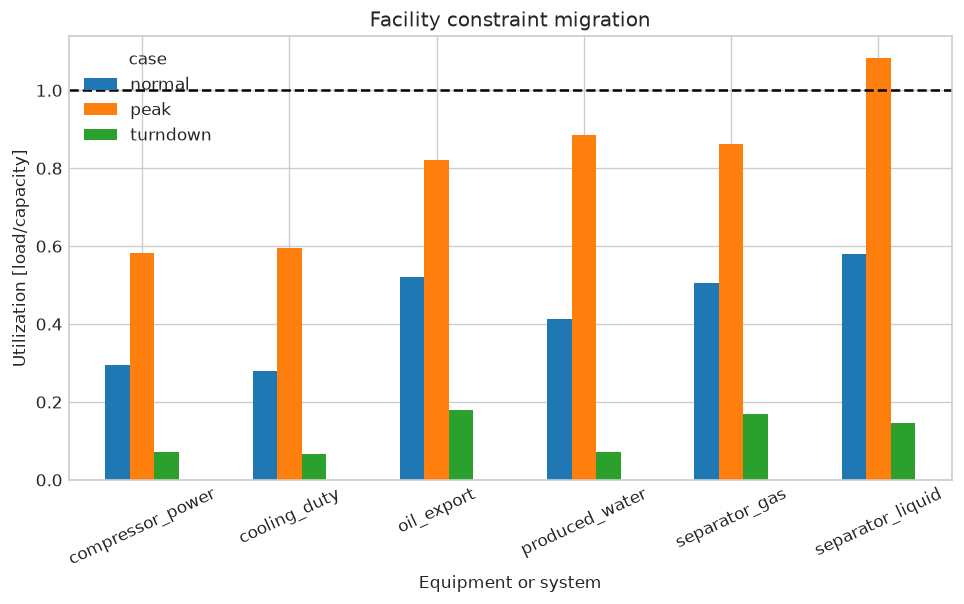

In [9]:
capacity_pivot = utilization.pivot(
    index="equipment",
    columns="case",
    values="utilization_fraction",
)
capacity_figure, capacity_axis = plt.subplots(figsize=(9.5, 4.8))
capacity_pivot.plot.bar(ax=capacity_axis)
capacity_axis.axhline(1.0, color="black", linestyle="--")
capacity_axis.set(
    xlabel="Equipment or system",
    ylabel="Utilization [load/capacity]",
    title="Facility constraint migration",
)
capacity_axis.tick_params(axis="x", rotation=25)
plt.show()


## 5. Produced water, chemicals, and liquid quality

A three-phase separator is only the first water-treatment step.
Hydrocyclones, compact flotation, filters, degassing, oil-in-water
monitoring, sand handling, reinjection or discharge, and chemical
compatibility must be evaluated. Chemical rates should be based on
active water or hydrocarbon volume, not total facility throughput.


In [10]:
water_management = inlet_envelope[
    ["case", "water_rate_Sm3_day"]
].copy()
water_management["inlet_oil_in_water_mg_L"] = [1200.0, 1600.0, 2100.0]
water_management["hydrocyclone_removal_fraction"] = [0.92, 0.90, 0.86]
water_management["polishing_removal_fraction"] = [0.70, 0.65, 0.55]
water_management["outlet_oil_in_water_mg_L"] = (
    water_management["inlet_oil_in_water_mg_L"]
    * (1.0 - water_management["hydrocyclone_removal_fraction"])
    * (1.0 - water_management["polishing_removal_fraction"])
)
water_management["scale_inhibitor_L_day"] = (
    water_management["water_rate_Sm3_day"] * 0.035
)
water_management["corrosion_inhibitor_L_day"] = (
    inlet_envelope["oil_rate_Sm3_day"] * 0.018
)
display(water_management)


,case,water_rate_Sm3_day,inlet_oil_in_water_mg_L,hydrocyclone_removal_fraction,polishing_removal_fraction,outlet_oil_in_water_mg_L,scale_inhibitor_L_day,corrosion_inhibitor_L_day
0,turndown,500.0,1200.0,0.92,0.70,28.8,17.5,16.2
1,normal,2900.0,1600.0,0.90,0.65,56.0,101.5,46.8
2,peak,6200.0,2100.0,0.86,0.55,132.3,217.0,73.8


## 6. Utilities, power, and emissions

Compressor shaft power, cooling duty, pumps, heating, and utilities
are aggregated. The operational emissions screen uses

$$m_{\mathrm{CO_2}}=E_{\mathrm{fuel}}\;EF_{\mathrm{CO_2}}$$

with an explicit fuel efficiency and emission factor. A historical
Volve emissions account must use measured fuel, flare, vent,
electricity, and allocation data from the Marketplace documents.


In [11]:
utilities = process_table[
    ["case", "compressor_power_MW", "aftercooler_duty_MW"]
].copy()
utilities["pump_and_auxiliary_power_MW"] = [0.45, 0.85, 1.25]
utilities["total_power_MW"] = (
    utilities["compressor_power_MW"]
    + utilities["pump_and_auxiliary_power_MW"]
)
generator_efficiency = 0.34
fuel_lower_heating_value_MJ_kg = 48.0
carbon_dioxide_factor_kg_kg_fuel = 2.75
utilities["fuel_rate_kg_s"] = (
    utilities["total_power_MW"]
    / generator_efficiency
    / fuel_lower_heating_value_MJ_kg
)
utilities["CO2_tonne_day"] = (
    utilities["fuel_rate_kg_s"]
    * carbon_dioxide_factor_kg_kg_fuel
    * vc.SECONDS_PER_DAY
    / 1000.0
)
utilities["CO2_kg_per_Sm3_oil"] = (
    utilities["CO2_tonne_day"]
    * 1000.0
    / inlet_envelope["oil_rate_Sm3_day"]
)
display(utilities)


,case,compressor_power_MW,aftercooler_duty_MW,pump_and_auxiliary_power_MW,total_power_MW,fuel_rate_kg_s,CO2_tonne_day,CO2_kg_per_Sm3_oil
0,turndown,0.602465,-0.802877,0.45,1.052465,0.064489,15.322649,17.025166
1,normal,2.504647,-3.370342,0.85,3.354647,0.205554,48.839708,18.784503
2,peak,4.956427,-7.137125,1.25,6.206427,0.380296,90.358281,22.038605


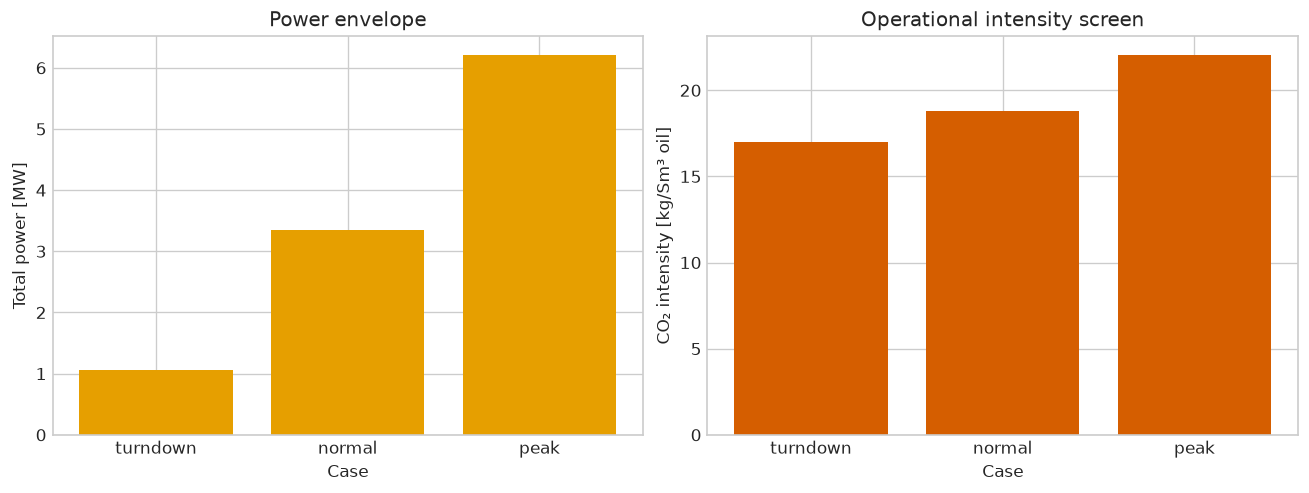

In [12]:
facility_figure, facility_axes = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.0),
    constrained_layout=True,
)
facility_axes[0].bar(
    utilities["case"],
    utilities["total_power_MW"],
    color="#E69F00",
)
facility_axes[0].set(
    xlabel="Case",
    ylabel="Total power [MW]",
    title="Power envelope",
)
facility_axes[1].bar(
    utilities["case"],
    utilities["CO2_kg_per_Sm3_oil"],
    color="#D55E00",
)
facility_axes[1].set(
    xlabel="Case",
    ylabel="CO₂ intensity [kg/Sm³ oil]",
    title="Operational intensity screen",
)
plt.show()


## 7. Availability, turndown, control, and safeguarding

Capacity alone is not an operating philosophy. The real facilities
evaluation should include compressor trains and recycle, separator
level and pressure control, slug reception, minimum stable flows,
flare and relief, ESD, blowdown, produced-water trip consequences,
maintenance states, redundancy, and restart. The table keeps these
requirements visible beside the steady-state model.


In [13]:
assurance_matrix = pd.DataFrame(
    {
        "topic": [
            "separator control",
            "compressor turndown",
            "slug handling",
            "produced-water trip",
            "power generation",
            "ESD and blowdown",
            "oil export interruption",
        ],
        "steady_state_evidence": [
            "phase loads and pressure",
            "power and flow envelope",
            "liquid capacity margin",
            "water rate and outlet quality",
            "power and fuel demand",
            "inventory basis only",
            "oil rate and storage interface",
        ],
        "required_follow_up": [
            "dynamic level and pressure control",
            "maps, antisurge, recycle, restart",
            "transient terrain and receiver volume",
            "routing, recycle, shutdown logic",
            "N+1 availability and load shedding",
            "relief, depressurization, flare radiation",
            "storage, offloading, and production curtailment",
        ],
    }
)
display(assurance_matrix)


,topic,steady_state_evidence,required_follow_up
0,separator control,phase loads and pressure,dynamic level and pressure control
1,compressor turndown,power and flow envelope,"maps, antisurge, recycle, restart"
2,slug handling,liquid capacity margin,transient terrain and receiver volume
3,produced-water trip,water rate and outlet quality,"routing, recycle, shutdown logic"
4,power generation,power and fuel demand,N+1 availability and load shedding
5,ESD and blowdown,inventory basis only,"relief, depressurization, flare radiation"
6,oil export interruption,oil rate and storage interface,"storage, offloading, and production curtailment"


In [14]:
facilities_contract_path = vc.write_contract(
    work_dir / "04_facilities_capacity_emissions.json",
    {
        "discipline": "facilities-processing",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "process_records": process_table.to_dict("records"),
        "utilization_records": utilization.to_dict("records"),
        "bottleneck_records": bottlenecks.to_dict("records"),
        "water_records": water_management.to_dict("records"),
        "utility_records": utilities.to_dict("records"),
        "limitations": [
            "teaching topology rather than as-built reconstruction",
            "screening capacities and emission factors",
            "steady state; dynamic safeguarding requires separate models",
        ],
    },
    source,
)
print(facilities_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/04_facilities_capacity_emissions.json


In [15]:
checks = {
    "three process cases ran": len(process_table) == 3,
    "mass balance closes": bool(
        process_table["relative_mass_residual"].abs().lt(1.0e-9).all()
    ),
    "compressor raises pressure": bool(
        process_table["export_pressure_bara"].gt(100.0).all()
    ),
    "compressor power positive": bool(
        process_table["compressor_power_MW"].gt(0.0).all()
    ),
    "peak power exceeds turndown": (
        process_table["compressor_power_MW"].iloc[-1]
        > process_table["compressor_power_MW"].iloc[0]
    ),
    "water quality finite": np.isfinite(
        water_management["outlet_oil_in_water_mg_L"]
    ).all(),
    "emissions positive": bool(
        utilities["CO2_tonne_day"].gt(0.0).all()
    ),
    "handoff exists": facilities_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(validation.loc[~validation["passed"], "check"].tolist())
print(f"All {len(checks)} facilities checks passed.")


All 8 facilities checks passed.


,check,passed
0,three process cases ran,True
1,mass balance closes,True
2,compressor raises pressure,True
3,compressor power positive,True
4,peak power exceeds turndown,True
5,water quality finite,True
6,emissions positive,True
7,handoff exists,True


## Interpretation and next notebook

The peak rate is not automatically the controlling case: late-life
water, mid-life gas compression, turndown, availability, and export
interruptions can move the bottleneck. Notebook 5 aligns measured
history, reservoir potential, well/SURF delivery, facility capacity,
export, uptime, economics, uncertainty, interventions, and
decommissioning in one auditable field-twin decision model.
